# **Project work: A mini segmentation challenge**

<div style="color:#777777;margin-top: -15px;">
<b>Course</b>: MSLS / CO4 |
<b>Version</b>: v1.3 <br><br>
<!-- 10.04.2025, v1.2: Fully refactored -->
<!-- 17.04.2026, v1.3: Introduced word count limits -->
</div>


**Student**: Oliver Hertach  
**Email**: hertaoli@students.zhaw.ch  
**University**: ZHAW  
**Semester**: SS26   
**Date**: 31.05.2026


<br>

## **Abstract**

*$\Rightarrow$ A brief summary of your project in 2-3 sentences.*



<br><br>

----

## **Table of contents**
<!-- Unfortunately, the following does not always work correctly -->
* [1. Dataset](#sec_dataset)  
* [2. Preprocessing](#sec_preprocessing)  
* [3. Manual segmentation](#sec_manual_segmentation)  
* [4. Automated segmentation](#sec_automated_segmentation)  
* [5. Evaluation](#sec_evaluation)  
* [6. Discussion](#sec_discussion)  
* [Appendix: Hints](#sec_hints)  


---

## **Prerequisites / Setup**

$\Rightarrow$ Special setup instructions, imports and configurations go here.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import PIL

# Jupyter / IPython configuration:
# Automatically reload modules when modified
%load_ext autoreload
%autoreload 2

# Enable vectorized output (for nicer plots)
%config InlineBackend.figure_formats = ["svg"]

# Inline backend configuration
%matplotlib inline

# Enable this line if you want to use the interactive widgets
# It requires the ipympl package to be installed.
#%matplotlib widget

import sys
sys.path.insert(0, "../")
import tools



new cwd: /home/oliver-hertach/Documents/Master/CO4/ClimbingVault


In [3]:
from pathlib import Path
import os

os.chdir(Path.cwd().parent)
print("new cwd:", Path.cwd())

new cwd: /home/oliver-hertach/Documents/Master/CO4


Fiji test

In [2]:
img = cv.imread("data/test-manual-segmentation/008.jpg")
mask = cv.imread("data/test-manual-segmentation/Mask_008.png", 0)

In [4]:
print(img.shape)
print(mask.shape)

(1864, 2800, 3)
(1864, 2800)


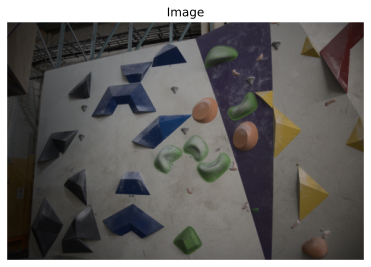

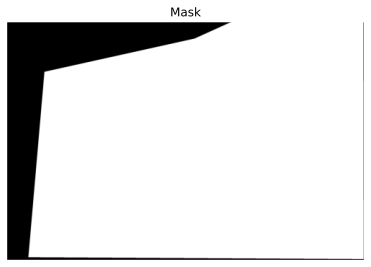

In [5]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Image")
plt.axis("off")

plt.figure()
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

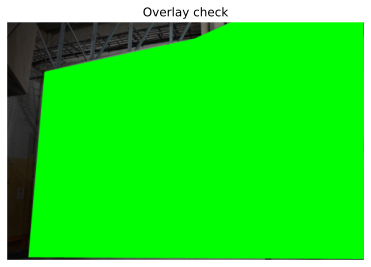

In [ ]:
overlay = img.copy()
mask_binary = (mask > 0)
overlay[mask > 0] = [0, 255, 0]

plt.imshow(cv.cvtColor(overlay, cv.COLOR_BGR2RGB))
plt.title("Overlay check")
plt.axis("off")
plt.show()

In [7]:
import numpy as np

print(np.unique(mask))

[  0 255]


In [8]:
print("img dtype:", img.dtype)
print("mask dtype:", mask.dtype)

img dtype: uint8
mask dtype: uint8


In [9]:
intersection = np.logical_and(mask > 0, mask > 0)
union = np.logical_or(mask > 0, mask > 0)
iou = intersection.sum() / union.sum()
print("dummy IoU sanity:", iou)

dummy IoU sanity: 1.0


---


<a id='sec_dataset'></a>

## **Dataset**

*$\Rightarrow$ Describe your dataset.*

### **Requirements**
* Provide a dataset with at least 10 image samples.
* The dataset must be no larger than 200 MB. If it exceeds this size, please contact the tutor in advance.
* Ensure that you have the rights to use and share the data (check the usage license).
* The images should clearly show a recognizable structure of interest.
* Avoid datasets with too much variation.
* Each student/team must use a different dataset!



---

<a id='sec_preprocessing'></a>

## **Preprocessing**

*$\Rightarrow$ Describe the pre-processing steps applied to enhance the input images.*

*Note: The specific steps will depend on your dataset and the intended application.*

### **Instructions:**
* Improve image quality by reducing noise, adjusting contrast, or normalizing intensity.
* Standardize image dimensions and formats for consistent input to analysis pipelines.
* Highlight or isolate relevant structures to support downstream processing.




---

<a id='sec_manual_segmentation'></a>

## **Manual segmentation**

*$\Rightarrow$ Describe the manual segmentation step*


### **Instructions:**
* Use a suitable tool to manually segment the structures of interest.  
* These segmentations will be needed for further analysis (or model training).  
* If your dataset already includes segmentation masks, you still need to demonstrate how such masks can be created manually.

---

<a id='sec_automated_segmentation'></a>

## **Automated Segmentation**

*$\Rightarrow$ Describe how the images are segmented using Python.*

### **Instructions:**
* Perform the segmentation in Python.
* You may use external libraries or tools (e.g., OpenCV, scikit-image).
* Implement a function `segment(image, ...)` that takes an image as input and returns a segmentation mask for the structure of interest.


---

<a id='sec_evaluation'></a>

## **Evaluation**

*$\Rightarrow$ Describe the evaluation of your results.*

### **Instructions:**
* Select an evaluation method to compare two binary segmentation masks and quantify how well they match (e.g., using the Dice score).
* Hint: Implement a function `evaluate(mask1, mask2)` that returns the chosen evaluation score(s).
* Calculate the mean and standard deviation of the scores across the entire dataset.



---

<a id='sec_discussion'></a>

## **Discussion**

*$\Rightarrow$ Briefly discuss your results and share your key observations and your experiences and leaernings.*



---

<a id='sec_references'></a>

## **References**

*$\Rightarrow$ List all relevant references (as URLs).*

*Also, clearly state whether you used generative AI tools (e.g., ChatGPT, GitHub Copilot) and describe how they were used.*



<br><br><br><br><br><br><br><br>

---

<a id='sec_hints'></a>

## **Appendix: Hints**

### **Markdown / HTML**

The following tutorials might be useful if you are not yet familiar with Markdown:

- [Quick overview](https://www.writethedocs.org/guide/writing/markdown/)
- [Markdown GitHub-style](https://docs.github.com/en/get-started/writing-on-github/getting-started-with-writing-and-formatting-on-github/basic-writing-and-formatting-syntax)
- [More detailed tutorial](https://www.datacamp.com/tutorial/markdown-in-jupyter-notebook)

By the way: In Markdown cells, you can also use simple HTML (e.g., `<key>...</key>` blocks) to gain more control over formatting.





### **Display images**

You may want to display your data, if possible. Here are a few ways to do that:

An easy method for displaying 2D images is using the [**Pillow**](https://pillow.readthedocs.io/en/stable/) library:

In [ ]:
# Option 1: Display an image with Pillow
path = "../data/images/kidney-cells-lowres.jpg"
image = PIL.Image.open(path)
display(image)                  

If you are working with the data as a NumPy array (e.g., when using the OpenCV interface), you can also display it using **matplotlib**.

In [ ]:
# Option 2: OpenCV / Matplotlib
path = "../data/images/ct-brain-slices.jpg"
image = cv.imread(path)
plt.imshow(image)
plt.axis("off")
plt.show()

For convenience, we also provide functions `display_image()` and `show_image()` the **tools** library, which includes various utilities used throughout this course.

In [ ]:
# Option 3a: Directly display a file
path = "../data/images/kidney-cells.jpg"
tools.display_image(path, scale=0.5)

# Option 3b: Similar, but with more options (e.g. title, frame, etc.)
tools.show_image(path, scale=0.5, 
                 title="Kidney cells", 
                 title_kwargs=dict(size=16, weight="bold", color="#7E487A"))

<br>
<br>


### **Display overlays**

When segmenting images, you may want to overlay the input image with the segmentation mask.  
There are several ways to do this – here are a few ideas:


In [ ]:
################################################
# Idea 1: Overlay a color on a grayscale image
################################################

# Enforce a (3-channel) color image
path_image = "../data/images/neurons-cultured.jpg"
image = cv.imread(path_image, cv.IMREAD_COLOR)
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Mask image
path_mask = "../data/images/neurons-cultured-mask.png"
mask = cv.imread(path_mask, cv.IMREAD_GRAYSCALE)

# Create overlay (RGB)
overlay_color = [255, 0, 0]
overlay_alpha = 0.3
overlay = image.copy()
overlay[mask > 0] = overlay_color
overlay = cv.addWeighted(image, 1 - overlay_alpha, overlay, overlay_alpha, 0)

# Display the images next to each other using a convenience function
tools.show_image_chain((image, overlay), titles=("Input", "Overlay"))

In [ ]:
################################################
# Idea 2: Overlay contours on a grayscale image
################################################

overlay_color = [255, 255, 0]
line_width = 1
contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
image_contours = image.copy()
cv.drawContours(image_contours, contours, -1, overlay_color, line_width)
tools.show_image_chain((image, image_contours), titles=("Input", "Contours"))

An advanced example: We can colorize different contours using distinct colors.

#### ***Strategy:***
- Use connected component labeling to assign a unique integer label to each region.
- Map each label to a different color by encoding it in the hue channel (in the HSV color space).
- Extract contours from the mask (ensure the mask is binary).
- Draw the contours with their assigned colors onto the original image.


In [ ]:
################################################
# Idea 3: Use colorized contours
################################################

# This will contain the result
image_contours = image.copy()

# Compute the "connected components" (= separate objects in the mask)
n_labels, labels = cv.connectedComponents(mask)

# Assign a different color to each label in the hue channel (HSV color space)
hue = np.uint8(150*labels/np.max(labels))
blank = 255*np.ones_like(hue)
labels = cv.merge([hue, blank, blank])

# Convert from HSV color space to RGB
labels = cv.cvtColor(labels, cv.COLOR_HSV2RGB)
# Set the background label (labels==0) to black
labels[labels==0] = 0

# Create a mask of the contours
line_width = 1
contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
mask_contours = cv.drawContours(np.zeros_like(mask), contours, -1, 255, line_width)

# Assign the colored labels only along the contours
image_contours[mask_contours>0] = labels[mask_contours>0]

# Display the result
tools.show_image_chain((image, image_contours), titles=("Input", "Labeled contours"))

<br>
<br>

### **How to convert a Jupyter notebook into a HTML:**

- Don't forget to **save your notebook** before converting!
- Install the conversion tool (if not already installed): `pip install nbconvert`
- Convert the notebook to an HTML file: `jupyter nbconvert --to html main.ipynb`  
  The HTML file will be saved in the same folder as your notebook.

In [ ]:
# Make sure you save this notebook, otherwise the HTML 
# output will not contain the latest version!!

# Make sure you have nbcovnert installed
# If not, you can install it with pip:
#       pip install nbconvert --quiet
# Save the notebook as HTML
#       jupyter nbconvert --to html main.ipynb